<a href="https://colab.research.google.com/github/pradipdas9040/Machine-Learning-2/blob/main/AgenticAI/02_Sequntial_prompt_chaining_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install langchain-ollama

In [2]:
%%capture
!sudo apt-get install -y zstd

In [3]:
%%capture
!curl -fsSL https://ollama.com/install.sh | sh

In [4]:
# Start Ollama service in the background
import subprocess
import os

# Set OLLAMA_HOST to '0.0.0.0' to make it accessible from inside the Colab VM.
os.environ['OLLAMA_HOST'] = '0.0.0.0'

# Start Ollama server in a new process
ollama_process = subprocess.Popen(['ollama', 'serve'])

# Wait a bit for the server to start (adjust if needed)
import time
time.sleep(5)

print("Ollama server started.")

Ollama server started.


In [5]:
%%capture
!ollama pull qwen2.5:3b

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict

In [7]:
model = ChatOllama(
    model="qwen2.5:3b",
    temperature=0
)

In [8]:
class LLMState(TypedDict):
  topicName: str
  outline: str
  description: str


def create_outline(state: LLMState) -> LLMState:
  topic_name = state['topicName']

  prompt = f'Generate a detailed outline on the topic {topic_name}'
  outline = model.invoke(prompt).content

  state['outline'] = outline
  return state

def create_description(state: LLMState) -> LLMState:
  title = state['topicName']
  outline = state['outline']

  prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'
  description = model.invoke(prompt).content

  state['description'] = description
  return state

In [9]:
graph = StateGraph(LLMState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_description", create_description)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_description")
graph.add_edge("create_description", END)

workflow = graph.compile()

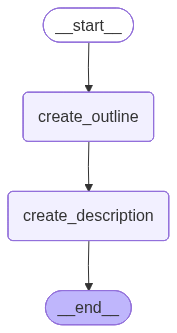

In [10]:
workflow

In [11]:
initial_state = {
    "topicName": "The future of AI"
}

result = workflow.invoke(initial_state)

In [12]:
print(result)

{'topicName': 'The future of AI', 'outline': 'Certainly! Here is a comprehensive outline for discussing "The Future of AI":\n\n### I. Introduction to Artificial Intelligence (AI)\n   - **Definition and History**: Brief overview of what AI is, its origins, and milestones in development.\n   - **Current State of AI**: Overview of current applications and advancements.\n\n### II. Technological Advancements Driving the Future of AI\n   - **Advances in Machine Learning**: Explanation of different types (supervised learning, unsupervised learning, reinforcement learning) and their importance.\n   - **Deep Learning**: Detailed explanation of neural networks, convolutional neural networks (CNNs), recurrent neural networks (RNNs), and transformers.\n   - **Natural Language Processing (NLP)**: Evolution from simple rule-based systems to modern NLP techniques like BERT, GPT-3, and transformer models.\n   - **Computer Vision**: Progress in image recognition, object detection, and segmentation usin

In [13]:
print(result['outline'])

Certainly! Here is a comprehensive outline for discussing "The Future of AI":

### I. Introduction to Artificial Intelligence (AI)
   - **Definition and History**: Brief overview of what AI is, its origins, and milestones in development.
   - **Current State of AI**: Overview of current applications and advancements.

### II. Technological Advancements Driving the Future of AI
   - **Advances in Machine Learning**: Explanation of different types (supervised learning, unsupervised learning, reinforcement learning) and their importance.
   - **Deep Learning**: Detailed explanation of neural networks, convolutional neural networks (CNNs), recurrent neural networks (RNNs), and transformers.
   - **Natural Language Processing (NLP)**: Evolution from simple rule-based systems to modern NLP techniques like BERT, GPT-3, and transformer models.
   - **Computer Vision**: Progress in image recognition, object detection, and segmentation using deep learning.

### III. Ethical Considerations and So

In [14]:
print(result['description'])

### The Future of Artificial Intelligence (AI): A Comprehensive Exploration

#### I. Introduction to Artificial Intelligence (AI)
Artificial intelligence is an interdisciplinary field that aims to create intelligent machines capable of performing tasks requiring human-like intelligence. It has its roots in the mid-20th century, with significant milestones including Alan Turing's seminal paper on computing and artificial intelligence in 1950.

**Current State of AI**: Today, AI powers a wide array of applications from virtual assistants like Siri and Alexa to sophisticated systems that analyze vast amounts of data for business insights. It is also integral to autonomous vehicles, medical diagnostics, and personalized recommendations across e-commerce platforms.

#### II. Technological Advancements Driving the Future of AI
**Machine Learning**: Machine learning involves training algorithms to make predictions or decisions based on historical data without being explicitly programmed. Key 